In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## IRIS DATASET

In [2]:
df = pd.read_csv('iris.csv')
print(df.shape)
print(df.info())
print(df.head())

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df.describe(include='object')

/tmp/ipykernel_58421/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,species
count,150
unique,3
top,setosa
freq,50


In [5]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print('Missing values:\n' , df.isnull().sum())

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


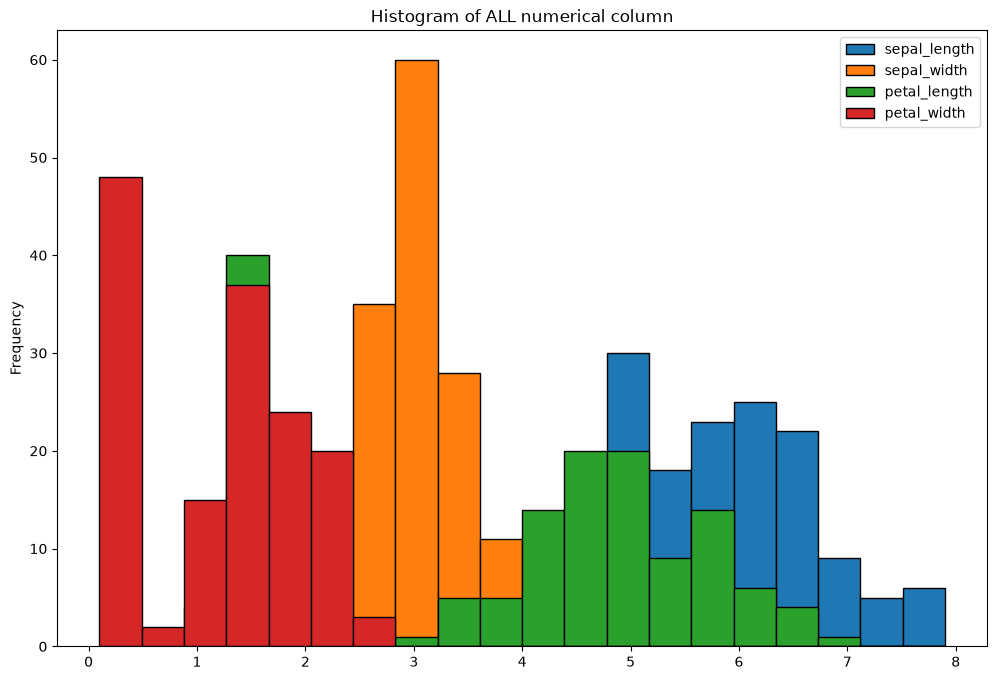

In [9]:
df.plot(kind='hist', edgecolor='black', bins = 20 , figsize=(12,8))
plt.title('Histogram of ALL numerical column')
plt.show()

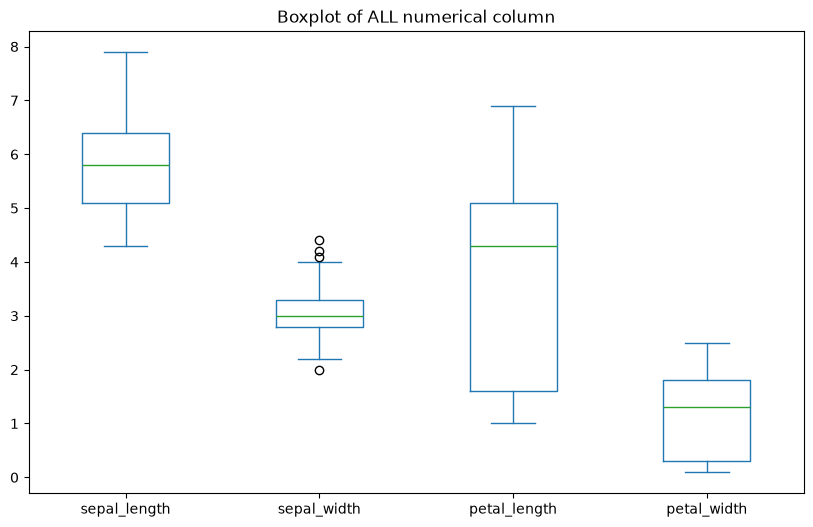

In [10]:
df.plot(kind='box', figsize=(10,6))
plt.title('Boxplot of ALL numerical column')
plt.show()

## Checking the outlieer real or error

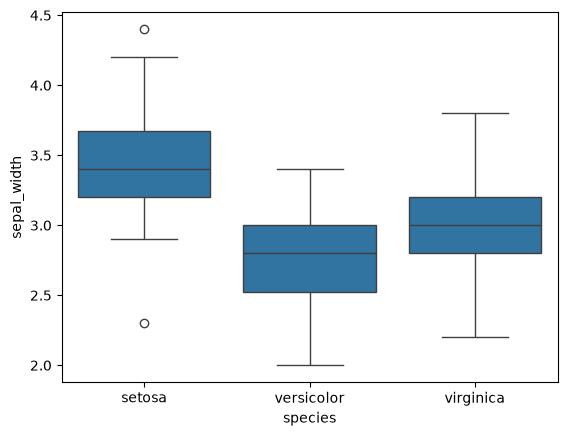

In [11]:
sns.boxplot(x='species', y='sepal_width', data=df)
plt.show()

In [12]:
print(df[df['sepal_width'] > 4.0])

    sepal_length  sepal_width  petal_length  petal_width species
15           5.7          4.4           1.5          0.4  setosa
32           5.2          4.1           1.5          0.1  setosa
33           5.5          4.2           1.4          0.2  setosa


# CONCLUSION OF UNIVARIATE


In [13]:
#- sepal_width mein 4 outliers mile (values 4.1, 4.2, 4.4)
#- Yeh natural variation hai, error nahi (isnull = 0 confirm karta hai)
#- Isliye outliers ko hataya nahi gaya

In [14]:
df[df['sepal_width'] > 4.0]

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='petal_length'>

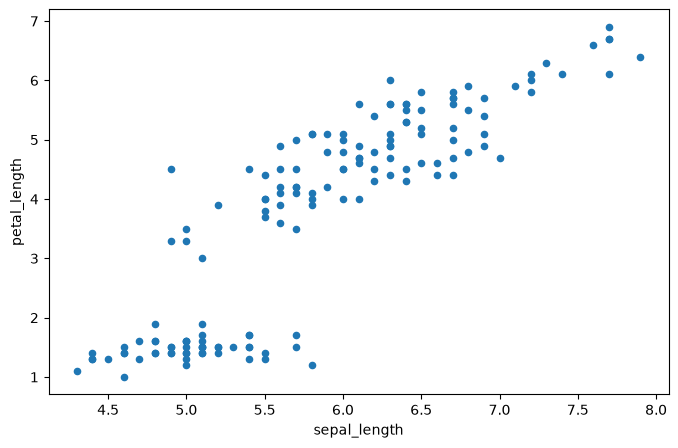

In [15]:
df.plot(kind='scatter', x='sepal_length', y='petal_length', figsize=(8,5))


In [16]:
df['sepal_length'].corr(df['petal_length'])

np.float64(0.873738142322971)

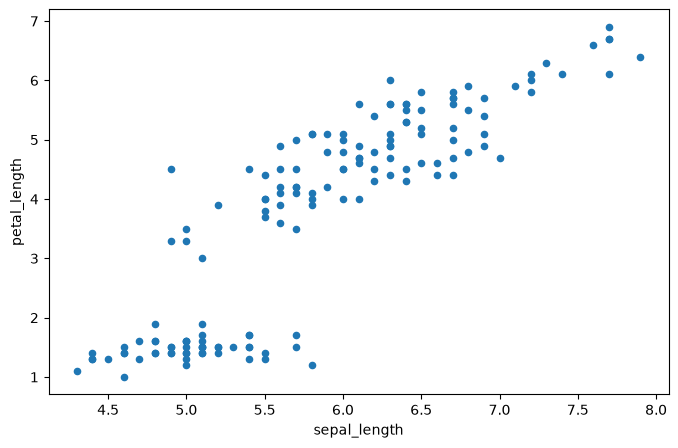

In [17]:
df.plot(kind='scatter', x='sepal_length', y='petal_length', figsize=(8,5))
plt.show()

In [18]:

df.select_dtypes(include='number').corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.118129,0.873738,0.820620
sepal_width,-0.118129,1.000000,-0.426028,-0.362894
petal_length,0.873738,-0.426028,1.000000,0.962772
petal_width,0.820620,-0.362894,0.962772,1.000000


<Axes: xlabel='species'>

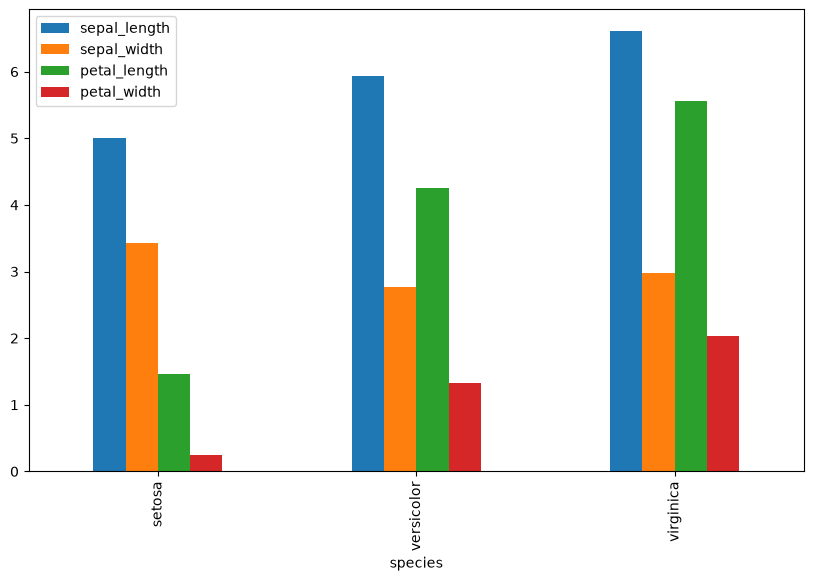

In [19]:
df.groupby('species').mean().plot(kind = 'bar' , figsize  = (10,6))


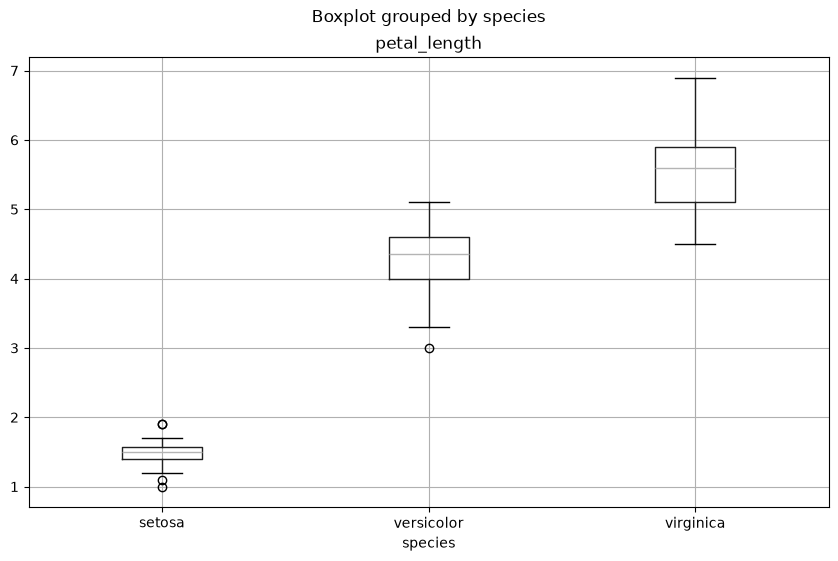

In [20]:
df.boxplot(column='petal_length', by='species', figsize=(10,6))
plt.show()

# Conculsion of bi variate analysis
petal_length aur petal_width mein strong positive (~0.96)

sepal_length aur petal_length bhi positive (~0.87)

Setosa sab features mein alag dikh rahi hai

Versicolor aur Virginica petal features se alag hoti hain

# MULTI VARIATRE ANALYSIS

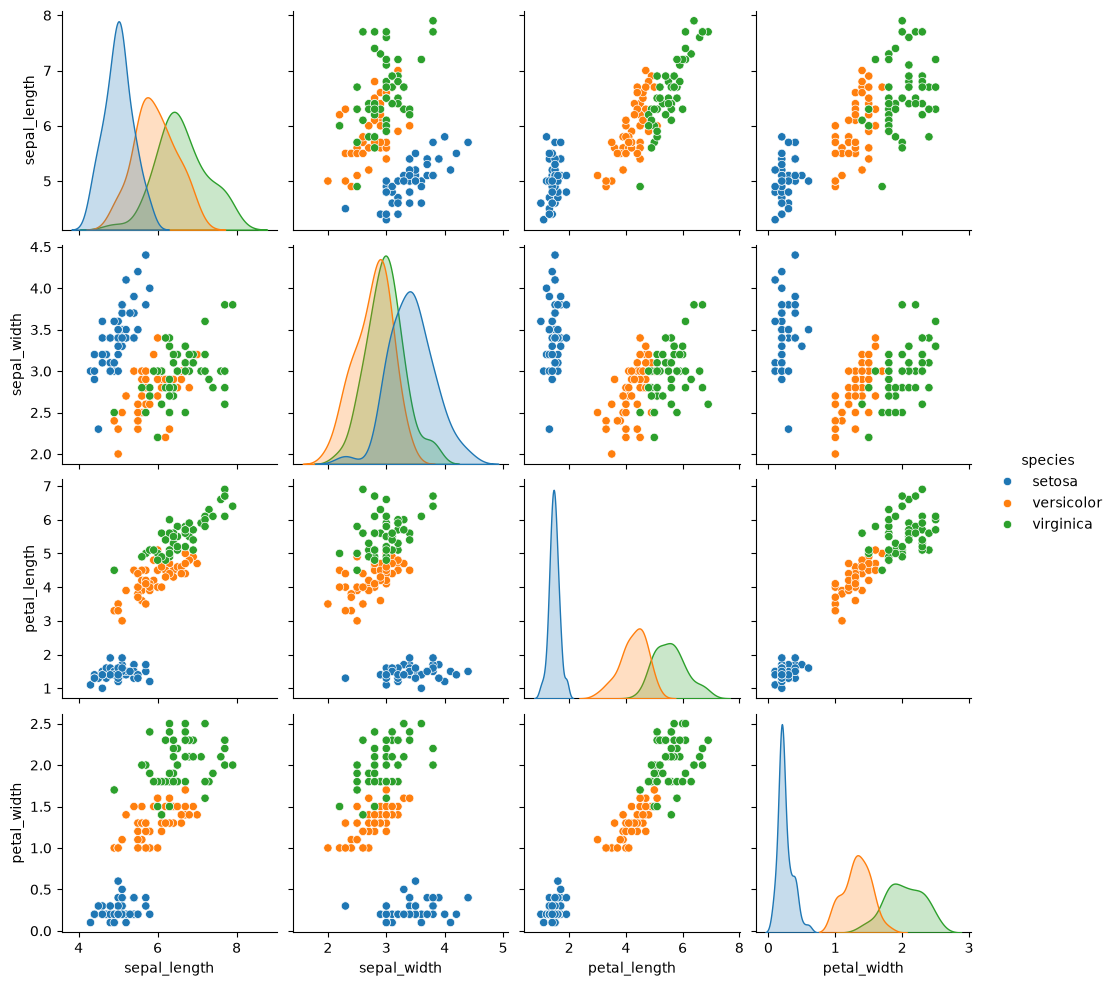

In [21]:
sns.pairplot(df , hue= 'species')
plt.show()

In [22]:
df['specie_num'] = df['species'].map({'setosa':0 , 'versicolor':1 , 'virginica':2})
df.select_dtypes(include='number').corr()

,sepal_length,sepal_width,petal_length,petal_width,specie_num
sepal_length,1.000000,-0.118129,0.873738,0.820620,0.786971
sepal_width,-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal_length,0.873738,-0.426028,1.000000,0.962772,0.949402
petal_width,0.820620,-0.362894,0.962772,1.000000,0.956514
specie_num,0.786971,-0.422987,0.949402,0.956514,1.000000


In [23]:
df['species_num'] = df['species'].map({'setosa':0, 'versicolor':1, 'virginica':2})

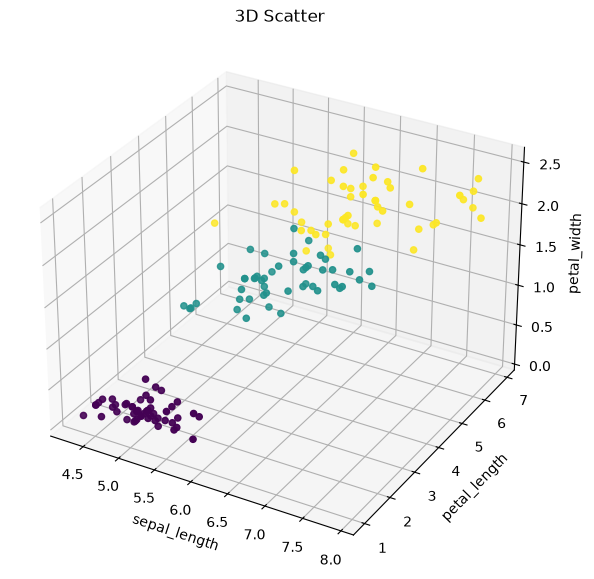

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['sepal_length'], df['petal_length'], df['petal_width'],
           c=df['species_num'], cmap='viridis')

ax.set_xlabel('sepal_length')
ax.set_ylabel('petal_length')
ax.set_zlabel('petal_width')
plt.title('3D Scatter')
plt.show()

In [25]:
df.describe()
df.groupby('species').mean()
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

# FINAL CONCLUSION OVERALL
**Univariate:**

4 numerical columns, 1 categorical

Koi missing value nahi, koi duplicate nahi

sepal_width mein 4 natural outliers (rakhe gaye)

petal_length aur petal_width bimodal hain

**Bivariate:**

petal_length aur petal_width mein strong positive correlation (~0.96)

sepal_length aur petal_length bhi positive (~0.87)

sepal_width ka baaki features se weak relation

**Multivariate:**

Setosa 100% alag

Versicolor aur Virginica thoda overlap

Petal features species separate karne ke liye best hain

Petal length sabse important feature hai

## ONE HOT ENCODING STARTED 

In [ ]:
#sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
5.1,3.5,1.4,0.2,1,0,0
4.9,3.0,1.4,0.2,1,0,0
4.7,3.2,1.3,0.2,1,0,0
4.6,3.1,1.5,0.2,1,0,0
5.0,3.6,1.4,0.2,1,0,0
5.4,3.9,1.7,0.4,1,0,0
4.6,3.4,1.4,0.3,1,0,0
5.0,3.4,1.5,0.2,1,0,0
4.4,2.9,1.4,0.2,1,0,0
4.9,3.1,1.5,0.1,1,0,0
5.4,3.7,1.5,0.2,1,0,0
4.8,3.4,1.6,0.2,1,0,0
4.8,3.0,1.4,0.1,1,0,0
4.3,3.0,1.1,0.1,1,0,0
5.8,4.0,1.2,0.2,1,0,0
5.7,4.4,1.5,0.4,1,0,0
5.4,3.9,1.3,0.4,1,0,0
5.1,3.5,1.4,0.3,1,0,0
5.7,3.8,1.7,0.3,1,0,0
5.1,3.8,1.5,0.3,1,0,0
5.4,3.4,1.7,0.2,1,0,0
5.1,3.7,1.5,0.4,1,0,0
4.6,3.6,1.0,0.2,1,0,0
5.1,3.3,1.7,0.5,1,0,0
4.8,3.4,1.9,0.2,1,0,0
5.0,3.0,1.6,0.2,1,0,0
5.0,3.4,1.6,0.4,1,0,0
5.2,3.5,1.5,0.2,1,0,0
5.2,3.4,1.4,0.2,1,0,0
4.7,3.2,1.6,0.2,1,0,0
4.8,3.1,1.6,0.2,1,0,0
5.4,3.4,1.5,0.4,1,0,0
5.2,4.1,1.5,0.1,1,0,0
5.5,4.2,1.4,0.2,1,0,0
4.9,3.1,1.5,0.2,1,0,0
5.0,3.2,1.2,0.2,1,0,0
5.5,3.5,1.3,0.2,1,0,0
4.9,3.6,1.4,0.1,1,0,0
4.4,3.0,1.3,0.2,1,0,0
5.1,3.4,1.5,0.2,1,0,0
5.0,3.5,1.3,0.3,1,0,0
4.5,2.3,1.3,0.3,1,0,0
4.4,3.2,1.3,0.2,1,0,0
5.0,3.5,1.6,0.6,1,0,0
5.1,3.8,1.9,0.4,1,0,0
4.8,3.0,1.4,0.3,1,0,0
5.1,3.8,1.6,0.2,1,0,0
4.6,3.2,1.4,0.2,1,0,0
5.3,3.7,1.5,0.2,1,0,0
5.0,3.3,1.4,0.2,1,0,0
7.0,3.2,4.7,1.4,0,1,0
6.4,3.2,4.5,1.5,0,1,0
6.9,3.1,4.9,1.5,0,1,0
5.5,2.3,4.0,1.3,0,1,0
6.5,2.8,4.6,1.5,0,1,0
5.7,2.8,4.5,1.3,0,1,0
6.3,3.3,4.7,1.6,0,1,0
4.9,2.4,3.3,1.0,0,1,0
6.6,2.9,4.6,1.3,0,1,0
5.2,2.7,3.9,1.4,0,1,0
5.0,2.0,3.5,1.0,0,1,0
5.9,3.0,4.2,1.5,0,1,0
6.0,2.2,4.0,1.0,0,1,0
6.1,2.9,4.7,1.4,0,1,0
5.6,2.9,3.6,1.3,0,1,0
6.7,3.1,4.4,1.4,0,1,0
5.6,3.0,4.5,1.5,0,1,0
5.8,2.7,4.1,1.0,0,1,0
6.2,2.2,4.5,1.5,0,1,0
5.6,2.5,3.9,1.1,0,1,0
5.9,3.2,4.8,1.8,0,1,0
6.1,2.8,4.0,1.3,0,1,0
6.3,2.5,4.9,1.5,0,1,0
6.1,2.8,4.7,1.2,0,1,0
6.4,2.9,4.3,1.3,0,1,0
6.6,3.0,4.4,1.4,0,1,0
6.8,2.8,4.8,1.4,0,1,0
6.7,3.0,5.0,1.7,0,1,0
6.0,2.9,4.5,1.5,0,1,0
5.7,2.6,3.5,1.0,0,1,0
5.5,2.4,3.8,1.1,0,1,0
5.5,2.4,3.7,1.0,0,1,0
5.8,2.7,3.9,1.2,0,1,0
6.0,2.7,5.1,1.6,0,1,0
5.4,3.0,4.5,1.5,0,1,0
6.0,3.4,4.5,1.6,0,1,0
6.7,3.1,4.7,1.5,0,1,0
6.3,2.3,4.4,1.3,0,1,0
5.6,3.0,4.1,1.3,0,1,0
5.5,2.5,4.0,1.3,0,1,0
5.5,2.6,4.4,1.2,0,1,0
6.1,3.0,4.6,1.4,0,1,0
5.8,2.6,4.0,1.2,0,1,0
5.0,2.3,3.3,1.0,0,1,0
5.6,2.7,4.2,1.3,0,1,0
5.7,3.0,4.2,1.2,0,1,0
5.7,2.9,4.2,1.3,0,1,0
6.2,2.9,4.3,1.3,0,1,0
5.1,2.5,3.0,1.1,0,1,0
5.7,2.8,4.1,1.3,0,1,0
6.3,3.3,6.0,2.5,0,0,1
5.8,2.7,5.1,1.9,0,0,1
7.1,3.0,5.9,2.1,0,0,1
6.3,2.9,5.6,1.8,0,0,1
6.5,3.0,5.8,2.2,0,0,1
7.6,3.0,6.6,2.1,0,0,1
4.9,2.5,4.5,1.7,0,0,1
7.3,2.9,6.3,1.8,0,0,1
6.7,2.5,5.8,1.8,0,0,1
7.2,3.6,6.1,2.5,0,0,1
6.5,3.2,5.1,2.0,0,0,1
6.4,2.7,5.3,1.9,0,0,1
6.8,3.0,5.5,2.1,0,0,1
5.7,2.5,5.0,2.0,0,0,1
5.8,2.8,5.1,2.4,0,0,1
6.4,3.2,5.3,2.3,0,0,1
6.5,3.0,5.5,1.8,0,0,1
7.7,3.8,6.7,2.2,0,0,1
7.7,2.6,6.9,2.3,0,0,1
6.0,2.2,5.0,1.5,0,0,1
6.9,3.2,5.7,2.3,0,0,1
5.6,2.8,4.9,2.0,0,0,1
7.7,2.8,6.7,2.0,0,0,1
6.3,2.7,4.9,1.8,0,0,1
6.7,3.3,5.7,2.1,0,0,1
7.2,3.2,6.0,1.8,0,0,1
6.2,2.8,4.8,1.8,0,0,1
6.1,3.0,4.9,1.8,0,0,1
6.4,2.8,5.6,2.1,0,0,1
7.2,3.0,5.8,1.6,0,0,1
7.4,2.8,6.1,1.9,0,0,1
7.9,3.8,6.4,2.0,0,0,1
6.4,2.8,5.6,2.2,0,0,1
6.3,2.8,5.1,1.5,0,0,1
6.1,2.6,5.6,1.4,0,0,1
7.7,3.0,6.1,2.3,0,0,1
6.3,3.4,5.6,2.4,0,0,1
6.4,3.1,5.5,1.8,0,0,1
6.0,3.0,4.8,1.8,0,0,1
6.9,3.1,5.4,2.1,0,0,1
6.7,3.1,5.6,2.4,0,0,1
6.9,3.1,5.1,2.3,0,0,1
5.8,2.7,5.1,1.9,0,0,1
6.8,3.2,5.9,2.3,0,0,1
6.7,3.3,5.7,2.5,0,0,1
6.7,3.0,5.2,2.3,0,0,1
6.3,2.5,5.0,1.9,0,0,1
6.5,3.0,5.2,2.0,0,0,1
6.2,3.4,5.4,2.3,0,0,1
5.9,3.0,5.1,1.8,0,0,1